# Building an MTCollection

The first step to analyzing a set of transfer functions is to load them into an `MTCollection` which is just a wrapper around an `MTH5` file.  The advantage to doing this is that you only have to do this once from the various transfer functions that you have, which might include various flavors of EDI, EMTFXML, J-files, Z-files, AVG-files, etc.  The other advantage is that now you have a database to work with: a single file where data is readily accessible vs. multiple ASCII files that need to be read in each time you want to do something.  

Using the class `MT` any<a name="fn1"></a>[<sup>[1]</sup>](#fn1) transfer function can be read into a generic transfer function container `MT`.  If you want to adjust `survey.id` or other metadata attributes you can do it from the `MT` object.  

<a name="fn1"></a>1. [^](#fn1) It works 100% of the time 50% of the time.  Most transfer function files are supported but if you find one is not raise an [issue](https://github.com/MTgeophysics/mtpy/issues)

## Test Data

Test data can be found at [mtpy-data](https://github.com/MTgeophysics/mtpy_data). Installation instructions are included in README.

In [1]:
from mtpy_data import GRID_LIST, PROFILE_LIST

## 1. Initiate MTCollection

First initiate an `MTCollection`, here we will save to our current working directory.

In [2]:
from pathlib import Path
from mtpy import MT, MTCollection

In [3]:
mtc = MTCollection()

In [4]:
mtc.open_collection(Path().cwd().joinpath("test_mt_collection.h5"))

26:05:06T23:12:20 | INFO | line:900 |mth5.mth5 | _initialize_file | Initialized MTH5 0.2.0 file c:\Users\peaco\OneDrive\Documents\GitHub\mtpy-v2\docs\source\notebooks\test_mt_collection.h5 in mode a
26:05:06T23:12:20 | WARNING | line:441 |mtpy.core.mt_collection | open_collection | Failed to initialize mt_data: Invalid HDF5 object reference


## 2. Load Transfer Functions

Step one is locating all the transfer function files you want to read in.  Here we will read in a couple different folders. If you have a couple different sets of data from different surveys, the MTCollection will store each in a survey group named by the `MT.survey_metadata.id`. However, this isn't a common attribute in EDI files, so if you want to separate them out add the correct survey ID.

<div class="alert alert-block alert-info">
<b>Note:</b> Loading transfer functions into an MTCollection can take some time so if you have over 100 be patient.  But you only have to do this once.
</div>

### 2a. Load Profile Data
The profile data does not have a `survey.id` in the EDI files so we will add one.

In [5]:
%%time
for fn in PROFILE_LIST:
    mt_object = MT()
    mt_object.read(fn)
    mt_object.survey_metadata.id = "profile"
    mtc.add_tf(mt_object)

26:05:06T23:12:20 | WARNING | line:591 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:05:06T23:12:20 | WARNING | line:591 |mt_metadata.base.metadata | update | Cannot update <class 'mt_metadata.timeseries.auxiliary.Auxiliary'> with <class 'mt_metadata.timeseries.magnetic.Magnetic'>
26:05:06T23:12:20 | WARNING | line:563 |mtpy.core.mt_collection | add_tf | If you are adding multiple transfer functions, suggest making a list of transfer functions first then adding the list using mt_collection.add_tf([list_of_tfs]). Otherwise adding transfer functions one by one will be slow.
26:05:06T23:12:20 | WARNING | line:1479 |mth5.mth5 | get_survey | /Experiment/Surveys/profile does not exist, check survey_list for existing names.
26:05:06T23:12:21 | INFO | line:749 |mtpy.core.mt_collection | _from_mt_object | added profile.15125A
26:05:06T23:12:21 | WARNING | line:591 |mt_metadata.b

### 2b. Load Grid Data
The grid data also does not have a `survey.id` so we will add one.

In [6]:
%%time
for fn in GRID_LIST:
    mt_object = MT()
    mt_object.read(fn)
    mt_object.survey_metadata.id = "grid"
    mtc.add_tf(mt_object)

26:05:06T23:12:27 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts_per_kilometer_per_nanotesla' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:05:06T23:12:27 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:05:06T23:12:27 | WARNING | line:432 |mt_metadata.common.units | get_unit_from_df | Unit 'millivolts' not found in accepted units, setting to 'unknown'. If this is an error raise an issue to add a unit. If an error needs to be raised, set allow_none=False.
26:05:06T23:12:27 | WARNING | line:563 |mtpy.core.mt_collection | add_tf | If you are adding multiple transfer functions, suggest making a list of transfer functions first then adding the list us

## 3. Working and Master Dataframes

`MTCollection` includes a summary table of the transfer functions that it contains in the form of a `pandas.DataFrame`, this is the `MTCollection.master_dataframe`.  There is also a `MTCollection.working_dataframe` which is a subset of the `master_dataframe` that the user can specify.  This allows the MTCollection to be a catch-all for all your transfer functions and then when you only want to work with a small subset from a certain survey or geographic area you can query the `master_dataframe` to set the `working_dataframe`.

### 3a. Profile Working Dataframe

Here we will choose to work only with data that has a `survey.id = 'profile'`.

In [7]:
mtc.working_dataframe = mtc.master_dataframe.loc[mtc.master_dataframe.survey == "profile"]

In [8]:
mtc.working_dataframe

,station,survey,latitude,longitude,elevation,tf_id,units,has_impedance,has_tipper,has_covariance,period_min,period_max,hdf5_reference,station_hdf5_reference
59,15125A,profile,-22.370806,149.188639,200.0,15125A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
60,15126A,profile,-22.370639,149.193500,200.0,15126A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
61,15127A,profile,-22.371028,149.198417,201.0,15127A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
62,15128A,profile,-22.370861,149.203306,200.0,15128A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
63,15129A,profile,-22.371083,149.208083,202.0,15129A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
64,15130A,profile,-22.371222,149.212972,201.0,15130A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
65,16122A,profile,-22.325611,149.174361,210.0,16122A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
66,16123A,profile,-22.325556,149.179056,213.0,16123A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
67,16124A,profile,-22.325694,149.184472,212.0,16124A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
68,16125A,profile,-22.325750,149.189306,219.0,16125A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>


#### Plot station locations

Now that we have queried for only those stations in the 'profile' survey lets plot the station locations just for a sanity check. Looks like the 1600 line and 1500 line are different, so let's pick just the 1500 line. 

<div class="alert alert-block alert-danger">
<b>Warning:</b> Southern hemisphere locations have issues with contextily and not sure why.  Below is an example on how to change the provider.  See contextily [providers](https://contextily.readthedocs.io/en/latest/intro_guide.html#Providers) for more details. 
</div>

26:05:06T23:13:04 | WARNING | line:186 |mtpy.imaging.plot_stations | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/14/9234/14981


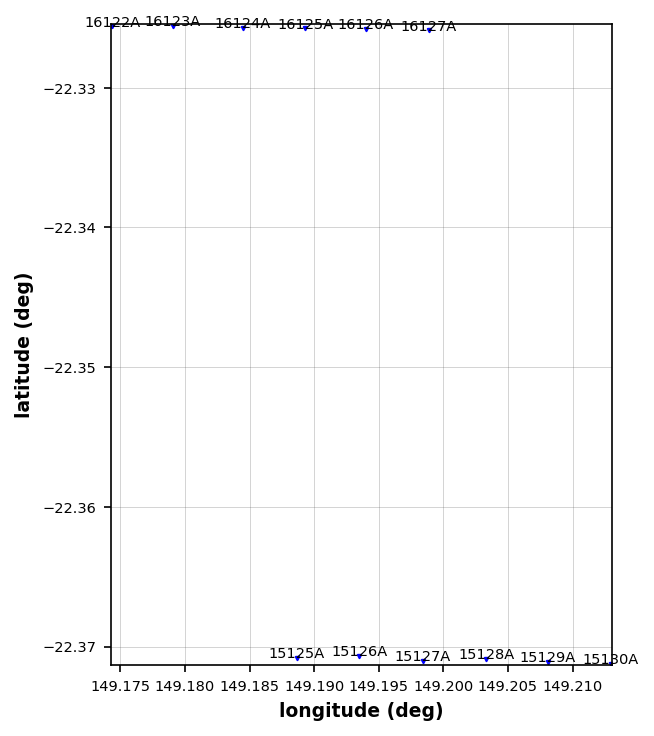

In [9]:
stations_plot = mtc.plot_stations(pad=.0001)

### Extract only the 15 line 

In [10]:
mtc.working_dataframe = mtc.working_dataframe.query('station.str.startswith("15")')

In [11]:
mtc.working_dataframe

,station,survey,latitude,longitude,elevation,tf_id,units,has_impedance,has_tipper,has_covariance,period_min,period_max,hdf5_reference,station_hdf5_reference
59,15125A,profile,-22.370806,149.188639,200.0,15125A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
60,15126A,profile,-22.370639,149.193500,200.0,15126A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
61,15127A,profile,-22.371028,149.198417,201.0,15127A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
62,15128A,profile,-22.370861,149.203306,200.0,15128A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
63,15129A,profile,-22.371083,149.208083,202.0,15129A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>
64,15130A,profile,-22.371222,149.212972,201.0,15130A,milliVolt per kilometer per nanoTesla,True,True,False,0.000096,2.857143,<HDF5 object reference>,<HDF5 object reference>


26:05:06T23:13:05 | WARNING | line:186 |mtpy.imaging.plot_stations | plot | Could not add base map because Tile URL resulted in a 404 error. Double-check your tile url:
https://basemap.nationalmap.gov/arcgis/rest/services/USGSTopo/MapServer/tile/15/18474/29963


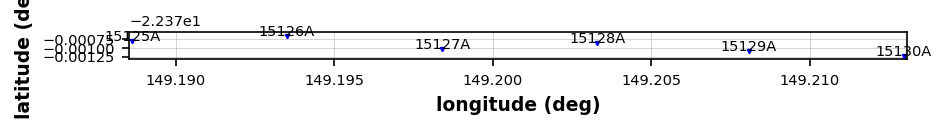

In [12]:
station_plot = mtc.plot_stations(pad=.0001)

### 3b. Grid Working DataFrame

Now lets get only the stations in the 'grid' survey and plot them.

In [13]:
mtc.working_dataframe = mtc.master_dataframe.loc[mtc.master_dataframe.survey == "grid"]

In [14]:
mtc.working_dataframe

,station,survey,latitude,longitude,elevation,tf_id,units,has_impedance,has_tipper,has_covariance,period_min,period_max,hdf5_reference,station_hdf5_reference
0,gv100,grid,38.611381,-118.535261,1437.400,gv100,unknown,True,True,False,0.001302,2048.000210,<HDF5 object reference>,<HDF5 object reference>
1,gv101,grid,38.594561,-118.351111,1540.550,gv101,unknown,True,True,False,0.001302,2048.000210,<HDF5 object reference>,<HDF5 object reference>
2,gv102,grid,38.593692,-118.276822,1554.800,gv102,unknown,True,True,False,0.001302,2048.000210,<HDF5 object reference>,<HDF5 object reference>
3,gv103,grid,38.585283,-118.202481,1543.900,gv103,unknown,True,True,False,0.001302,1365.000061,<HDF5 object reference>,<HDF5 object reference>
4,gv104,grid,38.596456,-118.136547,1801.800,gv104,unknown,True,True,False,0.001302,1365.000061,<HDF5 object reference>,<HDF5 object reference>
5,gv105,grid,38.594131,-118.071933,1901.600,gv105,unknown,True,True,False,0.001302,1365.000061,<HDF5 object reference>,<HDF5 object reference>
6,gv106,grid,38.598842,-117.940803,1653.269,gv106,unknown,True,True,False,0.001302,2048.000210,<HDF5 object reference>,<HDF5 object reference>
7,gv107,grid,38.612339,-117.882392,1753.700,gv107,unknown,True,True,False,0.001302,2048.000210,<HDF5 object reference>,<HDF5 object reference>
8,gv108,grid,38.691575,-118.501819,1904.900,gv108,unknown,True,True,False,0.001302,2048.000210,<HDF5 object reference>,<HDF5 object reference>
9,gv109,grid,38.721022,-118.421311,1769.400,gv109,unknown,True,True,False,0.001302,2048.000210,<HDF5 object reference>,<HDF5 object reference>


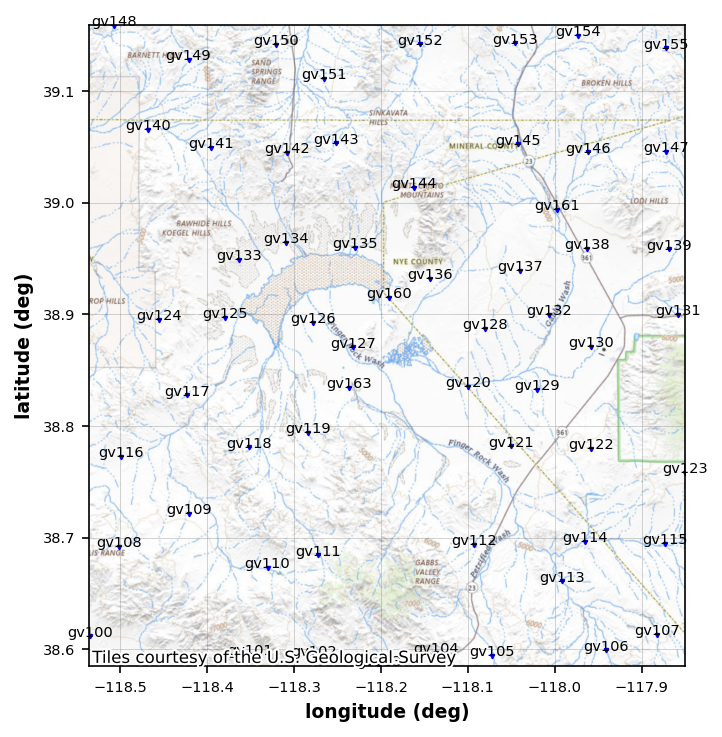

In [15]:
station_plot = mtc.plot_stations(pad=.0005)

### Change Basemap

`contextily` has good options for basemaps, you can check out all the options at https://contextily.readthedocs.io/en/latest/providers_deepdive.html.

Below is an exmaple of how to change the source basemap to the National Geographic World Map.

In [16]:
import contextily as cx

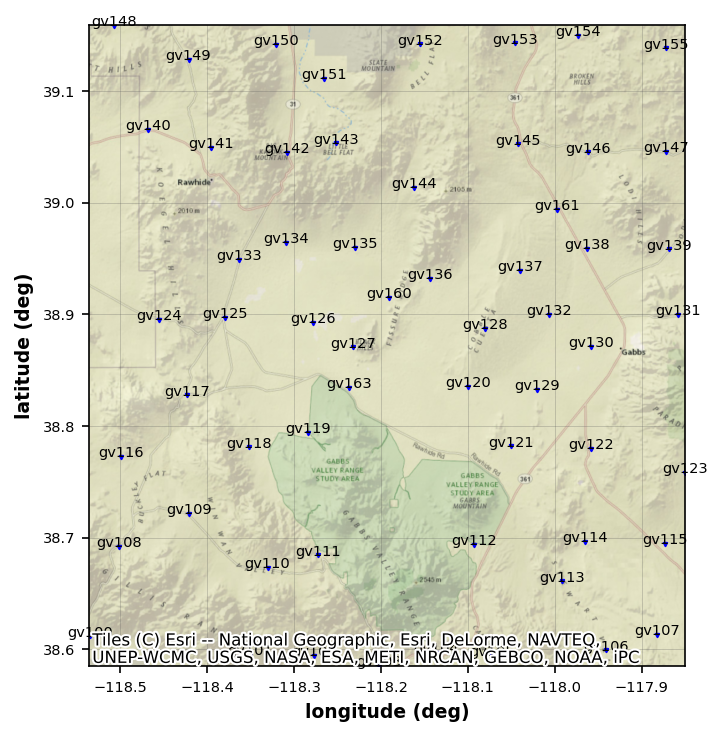

In [17]:
station_plot.cx_source = cx.providers.Esri.NatGeoWorldMap
station_plot.redraw_plot()

## 4. MTCollection vs MTData

`MTCollection` is the persistent storage interface (backed by MTH5), while `MTData` is the in-memory object used for fast manipulation and analysis.

A useful update is that `open_collection(...)` now initializes an `MTData` object directly on the collection as `mc.mt_data`, so you can immediately work in-memory after opening the file.

`MTData` now exposes a DataTree accessor at `tree.mt` for structural station operations (path lookup, get/set station datasets, station-wise transforms, and selection). This keeps station-level workflows explicit and fast in RAM.

```python
from mtpy import MT, MTData, MTCollection

# Build MTData directly from TF files (no MTH5 required)
md = MTData()
for filename in list_of_tf_files:
    mt_object = MT()
    mt_object.read(filename)
    md.add_station(mt_object)

# DataTree accessor utilities on MTData
station_paths = md.tree.mt.station_paths
station_ds = md.tree.mt.get_station_dataset(station_paths[0])

# Apply a station-wise transform (returns a new tree by default)
rotated_tree = md.tree.mt.map_stations(lambda ds: ds.tf.rotate(10))

# Persist to MTH5
with MTCollection() as mc:
    mc.open_collection("/path/to/mth5_file.h5")

    # Convenience: immediately available MTData view
    current_md = mc.mt_data

    # Collection-level convenience for station-wise transforms
    mc.map_stations(lambda ds: ds.tf.rotate(10), write_back=False)

    # Write edited MTData back to collection
    mc.from_mt_data_tree(md)
```

## 5. Close MTCollection

<div class="alert alert-block alert-danger">
<b>Important:</b> You need to close the MTCollection otherwise the file may get corrupted and you'll have to make the file all over again.  Note that once the file is closed the transfer functions are no longer available.  Therefore it is wise to convert to an MTData object.
</div>

In [18]:
mtc.close_collection()

26:05:06T23:13:22 | INFO | line:1035 |mth5.mth5 | close_mth5 | Flushing and closing c:\Users\peaco\OneDrive\Documents\GitHub\mtpy-v2\docs\source\notebooks\test_mt_collection.h5


### 5a. Context Manager

If you just want to build an MTH5 file and then close it the best way to do that is using the context manager:

```
with MTCollection() as mc:
    mc.open_collection("/path/to/mth5_file.h5")
    # add data to the files
    
```

